# Machine Learning : Flight Ticket Price Prediction

## 1. Import Libraries & Load Dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("C:\\Users\\DELL\\Downloads\\archive (2)\\Clean_Dataset.csv")   

In [2]:
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [3]:
print("Shape of dataset( rows and columns) :",df.shape)
df.info()

Shape of dataset( rows and columns) : (300153, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [4]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64


## 2. Understanding the Dataset

In [5]:
df['airline'].unique()
df['source_city'].unique()
df['destination_city'].unique()

array(['Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai', 'Delhi'],
      dtype=object)

## 3.Exploratory Data Analysis (EDA)

In [6]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)


Numeric columns: Index(['Unnamed: 0', 'duration', 'days_left', 'price'], dtype='object')
Categorical columns: Index(['airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class'],
      dtype='object')


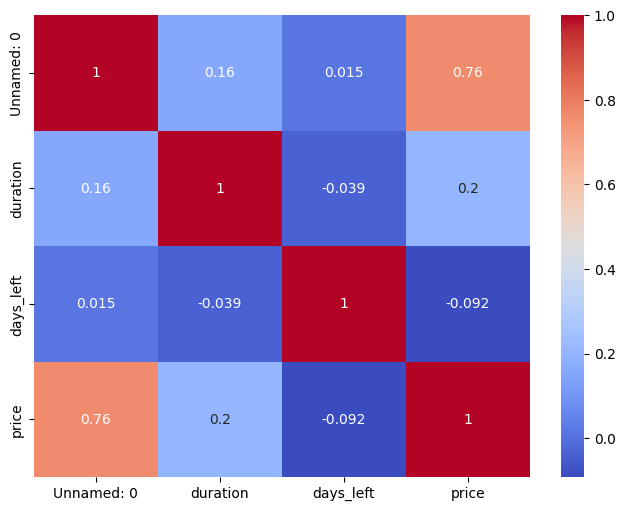

In [7]:
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.show()

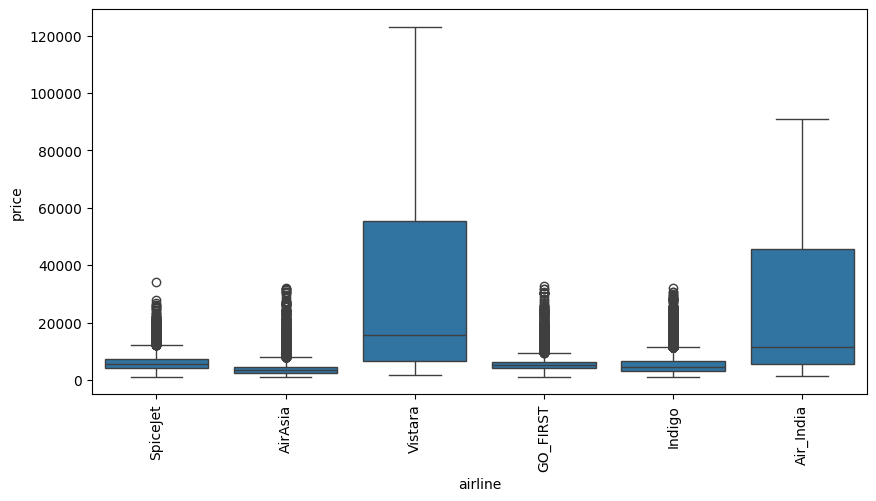

In [9]:
plt.figure(figsize=(10,5))
sns.boxplot(x='airline', y='price', data=df)
plt.xticks(rotation=90)
plt.show()

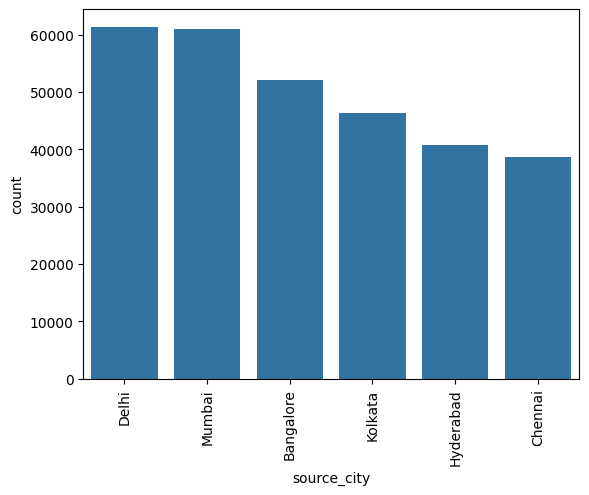

In [13]:
sns.countplot(x='source_city', data=df)
plt.xticks(rotation=90)
plt.show()

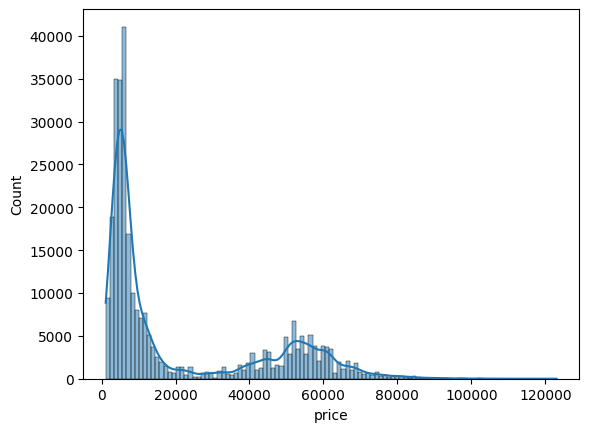

In [14]:
sns.histplot(df['price'], kde=True)
plt.show()

# 4. Data Preprocessing

In [15]:
df.drop_duplicates(inplace=True)

In [17]:
df.drop("Unnamed: 0", axis=1, inplace=True)

In [18]:
df["stops"].unique()

array(['zero', 'one', 'two_or_more'], dtype=object)

In [19]:
df["stops"] = df["stops"].map({
    "zero": 0,
    "one": 1,
    "two_or_more": 2
})

In [20]:
df.drop("flight", axis=1, inplace=True)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   source_city       300153 non-null  object 
 2   departure_time    300153 non-null  object 
 3   stops             300153 non-null  int64  
 4   arrival_time      300153 non-null  object 
 5   destination_city  300153 non-null  object 
 6   class             300153 non-null  object 
 7   duration          300153 non-null  float64
 8   days_left         300153 non-null  int64  
 9   price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 22.9+ MB


In [22]:
df = pd.get_dummies(df, drop_first=True)

# 5. Model Training

In [23]:
X = df.drop("price", axis=1)
y = df["price"]

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model 1 - Linear Regression

In [25]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

## Model 2 - Random Forest

In [28]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

## Model 3 - Gradient Boosting / XG Boost

In [29]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

## Model Evaluation

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(y_test, y_pred):
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R2 Score:", r2_score(y_test, y_pred))
    print("-"*40)

print("Linear Regression")
evaluate(y_test, y_pred_lr)

print("Random Forest")
evaluate(y_test, y_pred_rf)

print("Gradient Boosting")
evaluate(y_test, y_pred_gb)

Linear Regression
MAE: 4500.712501541786
RMSE: 6814.935635222577
R2 Score: 0.9099031138535915
----------------------------------------
Random Forest
MAE: 1086.1557405594413
RMSE: 2799.6915931099093
R2 Score: 0.9847942918342021
----------------------------------------
Gradient Boosting
MAE: 2972.0569197453515
RMSE: 5001.120430806615
R2 Score: 0.9514799890396431
----------------------------------------


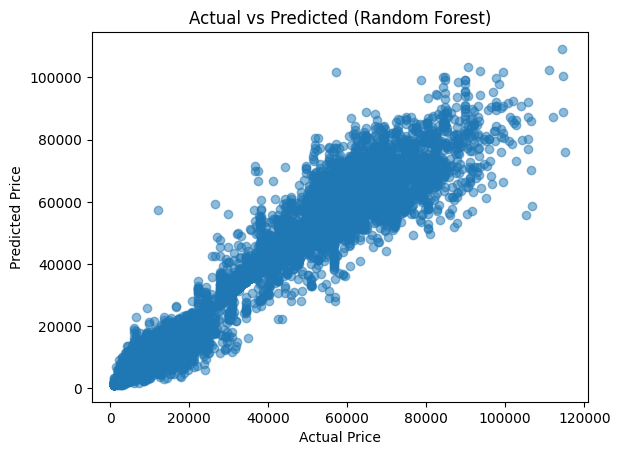

In [31]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

In [32]:
import pandas as pd

feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

feat_imp.head(10)

,Feature,Importance
28,class_Economy,0.879856
1,duration,0.058735
2,days_left,0.018535
7,airline_Vistara,0.005230
3,airline_Air_India,0.005079
9,source_city_Delhi,0.003910
24,destination_city_Delhi,0.003644
12,source_city_Mumbai,0.002442
27,destination_city_Mumbai,0.002081
25,destination_city_Hyderabad,0.001915


Install Streamlit if needed:

```bash
pip install streamlit
```

In [34]:
import pickle

pickle.dump(rf, open("flight_model.pkl", "wb"))

In [35]:
pickle.dump(X.columns, open("model_columns.pkl", "wb"))